# Analysis of RPKM Tables

In [1]:
import os
import numpy as np
import pandas as pd

import mygene

import matplotlib.pyplot as plt
import plotly.express as px


rpkm = r"../rpkm_values/rpkm_combined.txt"
healthy = r"../rpkm_values/rpkm_healthy/rpkm_values_healthy.txt"
t2d = r"../rpkm_values/rpkm_t2d/rpkm_values_t2d.txt"

In [2]:
df = pd.read_csv(rpkm, sep='\t')
df_healthy = pd.read_csv(healthy, sep='\t')
df_t2d = pd.read_csv(t2d, sep='\t')

In [3]:
# df.columns.tolist()

In [4]:
print(len(df.columns))
print(len(df_healthy.columns))
print(len(df_t2d.columns))

142
97
45


In [5]:
# Transpose the RPKM dataframe so rows become samples
df_t = df.T

# Now determine sample labels
healthy_samples = set(df_healthy.columns)
t2d_samples = set(df_t2d.columns)

# Assign condition based on sample name
df_t['condition'] = ['healthy' if sample in healthy_samples else 't2d' for sample in df_t.index]
df_t.head()

,ENSG00000160072,ENSG00000279928,ENSG00000228037,ENSG00000142611,ENSG00000284616,ENSG00000157911,ENSG00000269896,ENSG00000228463,ENSG00000260972,ENSG00000224340,...,ENSG00000276345,ENSG00000273532,ENSG00000275063,ENSG00000277856,ENSG00000271254,ENSG00000275987,ENSG00000268674,ENSG00000277475,ENSG00000275405,condition
AZ_A8.bam,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,healthy
AZ_C10.bam,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,healthy
AZ_C4.bam,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,healthy
AZ_D6.bam,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.866315,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,healthy
AZ_E7.bam,0.073673,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.131931,0.0,0.0,0.0,0.0,healthy


In [6]:
df_t['donor'] = df_t.index.str.split('_').str[0]

## Beta-cell Confirmation

In [7]:
mg = mygene.MyGeneInfo()

# Query gene symbols
gene_symbols = ['GCG', 'INS', 'PPY', 'SST']
results = mg.querymany(gene_symbols, scopes='symbol', fields='ensembl.gene', species='human')

# Build dict symbol -> Ensembl ID
symbol_to_ensembl_small = {r['query']: r['ensembl']['gene'] if isinstance(r['ensembl'], dict) else r['ensembl'][0]['gene']
                     for r in results if 'ensembl' in r}


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


In [8]:
symbol_to_ensembl_small

{'GCG': 'ENSG00000115263',
 'INS': 'ENSG00000254647',
 'PPY': 'ENSG00000108849',
 'SST': 'ENSG00000157005'}

In [9]:
# Create a subset with just those 4 genes
subset = df_t[list(symbol_to_ensembl_small.values())].copy()
subset.columns = symbol_to_ensembl_small.keys()  # Rename to gene symbols
subset
# Normalize by log2
log_subset = np.log2(subset + 1)
log_subset

,GCG,INS,PPY,SST
AZ_A8.bam,4.787959,16.437794,6.413168,5.555190
AZ_C10.bam,5.160662,15.960881,1.175719,6.234554
AZ_C4.bam,5.275064,17.133383,1.060861,5.122213
AZ_D6.bam,4.657026,14.429525,7.356343,5.765354
AZ_E7.bam,7.975794,16.332966,0.000000,6.733543
...,...,...,...,...
HP1526901T2D_N12.bam,4.358434,15.255884,3.031123,1.978236
HP1526901T2D_N13.bam,4.501219,15.279048,2.316015,2.911368
HP1526901T2D_N23.bam,3.546375,13.924297,2.808932,1.791585
HP1526901T2D_N3.bam,8.056463,14.997494,2.688993,3.690260


In [10]:
# Sort df_t by condition
df_sorted = df_t.sort_values(by='condition')

# Get just the log2(RPKM + 1) expression of selected genes, sorted by sample order
log_subset_sorted = np.log2(df_sorted[list(symbol_to_ensembl_small.values())] + 1)
log_subset_sorted.columns = symbol_to_ensembl_small.keys()

transition_idx = df_sorted['condition'].eq('t2d').idxmax()
transition_pos = df_sorted.index.get_loc(transition_idx)


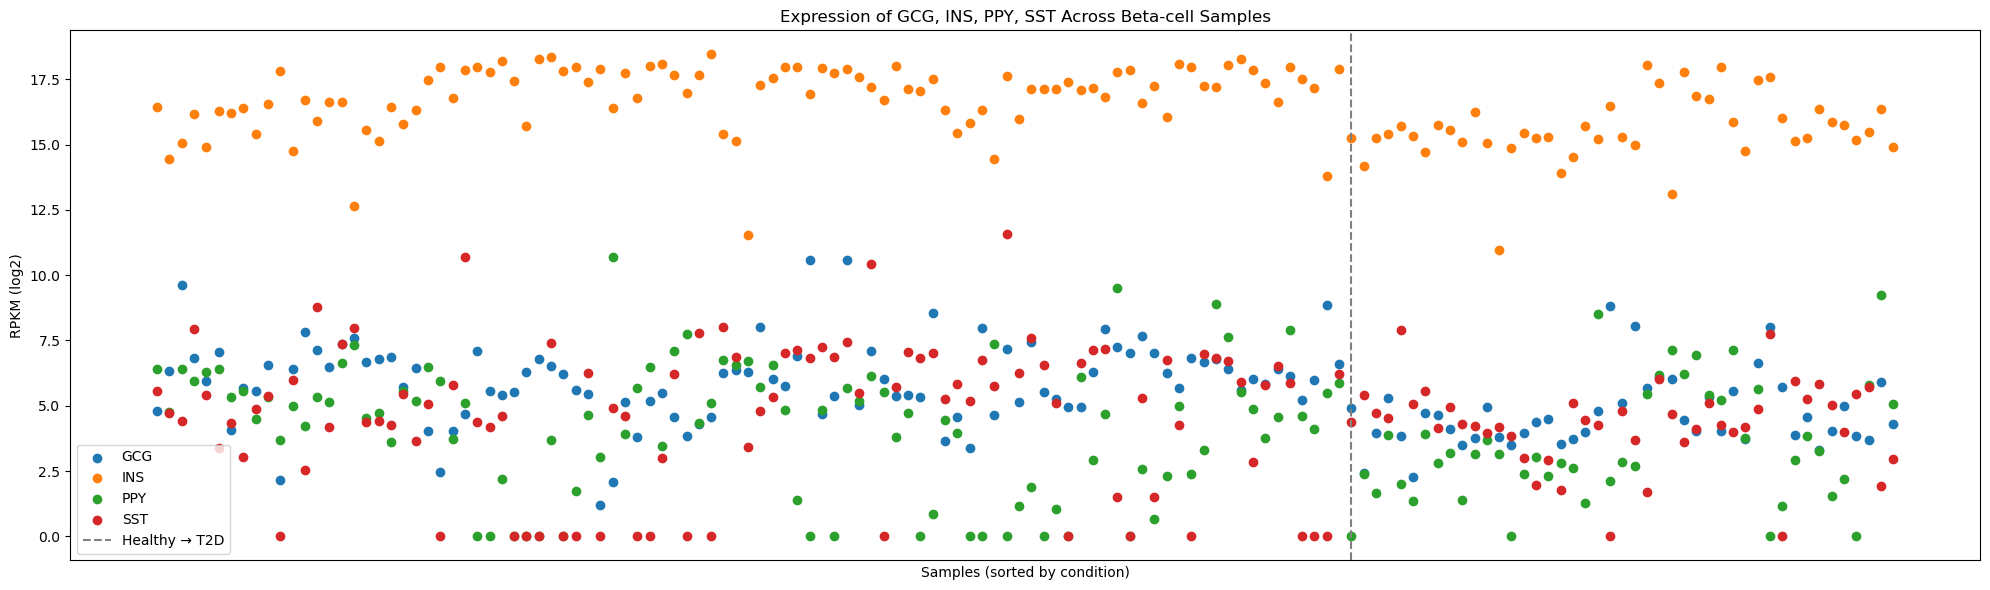

In [11]:
plt.figure(figsize=(20, 6))

for gene in ['GCG', 'INS', 'PPY', 'SST']:
    plt.scatter(log_subset_sorted.index, log_subset_sorted[gene], label=gene)

# Add vertical dotted line at transition
plt.axvline(x=transition_pos, linestyle='--', color='gray', label='Healthy → T2D')

# Simplify x-axis
plt.xticks([], [])  # Hide x-tick labels
plt.ylabel('RPKM (log2)')
plt.xlabel('Samples (sorted by condition)')
plt.title('Expression of GCG, INS, PPY, SST Across Beta-cell Samples')
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
# Melt the DataFrame
long_df = log_subset_sorted[['GCG', 'INS', 'PPY', 'SST']].copy()
condition_labels = pd.Series(condition_labels, index=log_subset_sorted.index)
long_df['condition'] = condition_labels
long_df = long_df.melt(id_vars='condition', var_name='Gene', value_name='Expression')

In [ ]:
condition_labels

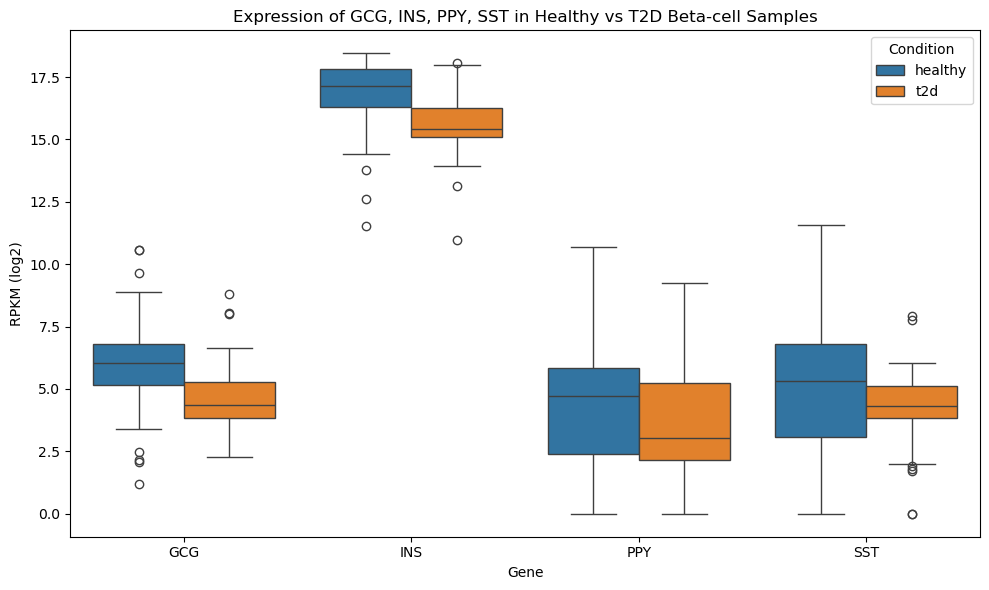

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='Gene', y='Expression', hue='condition', data=long_df)
plt.ylabel('RPKM (log2)')
plt.title('Expression of GCG, INS, PPY, SST in Healthy vs T2D Beta-cell Samples')
plt.legend(title='Condition')
plt.tight_layout()
plt.show()


In [30]:
from scipy.stats import mannwhitneyu

genes = ['GCG', 'INS', 'PPY', 'SST']
results = []

for gene in genes:
    healthy_values = log_subset_sorted.loc[condition_labels == 'healthy', gene].dropna()
    t2d_values = log_subset_sorted.loc[condition_labels == 't2d', gene].dropna()
    
    if len(healthy_values) == 0 or len(t2d_values) == 0:
        print(f"{gene}: One group is empty. Skipping.")
        continue

    stat, p = mannwhitneyu(healthy_values, t2d_values, alternative='two-sided')
    results.append((gene, stat, p))

# Display results
for gene, stat, p in results:
    print(f"{gene}: U-statistic={stat:.2f}, p-value={p:.4f}")

print(results)

GCG: U-statistic=3367.00, p-value=0.0000
INS: U-statistic=3438.00, p-value=0.0000
PPY: U-statistic=2617.00, p-value=0.0568
SST: U-statistic=2689.00, p-value=0.0263
[('GCG', 3367.0, 2.0874964229162652e-07), ('INS', 3438.0, 3.740623914069236e-08), ('PPY', 2617.0, 0.05675463792123318), ('SST', 2689.0, 0.0262698723679572)]


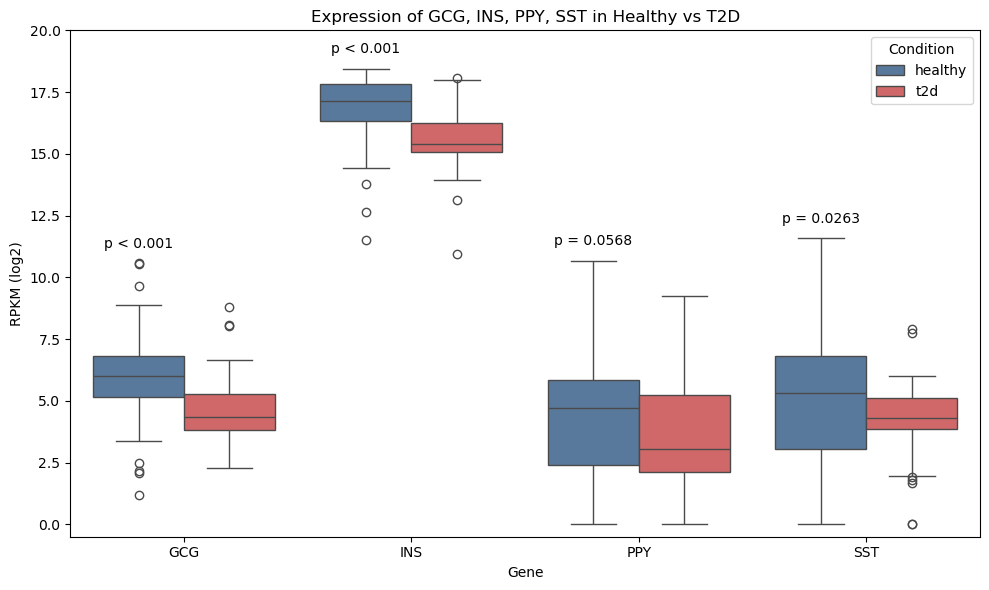

In [38]:
# P-values you already computed
pvals = {
    'GCG': 0.0000,
    'INS': 0.0000,
    'PPY': 0.0568,
    'SST': 0.0263,
}

custom_palette = {'healthy': '#4E79A7', 't2d': '#E15759'}

plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='Gene', y='Expression', hue='condition', data=long_df, palette=custom_palette)
plt.ylabel('RPKM (log2)')
plt.title('Expression of GCG, INS, PPY, SST in Healthy vs T2D')

# Add p-value annotations
x_offset = {'GCG': -0.2, 'INS': -0.2, 'PPY': -0.2, 'SST': -0.2}
for i, gene in enumerate(['GCG', 'INS', 'PPY', 'SST']):
    y_max = long_df[long_df['Gene'] == gene]['Expression'].max()
    pval = pvals[gene]
    text = f"p = {pval:.4f}" if pval >= 0.001 else "p < 0.001"
    plt.text(i + x_offset[gene], y_max + 0.5, text, ha='center', va='bottom', fontsize=10)

plt.ylim((-0.5, 20))
plt.legend(title='Condition')
plt.tight_layout()
plt.show()


In [12]:
# Sort by INS decreasing
ensg_ins = symbol_to_ensembl_small['INS']
df_sorted = df_t.sort_values(by=ensg_ins, ascending=False)
log_subset_sorted = np.log2(df_sorted[list(symbol_to_ensembl_small.values())] + 1)
log_subset_sorted.columns = symbol_to_ensembl_small.keys()  # rename to gene symbols


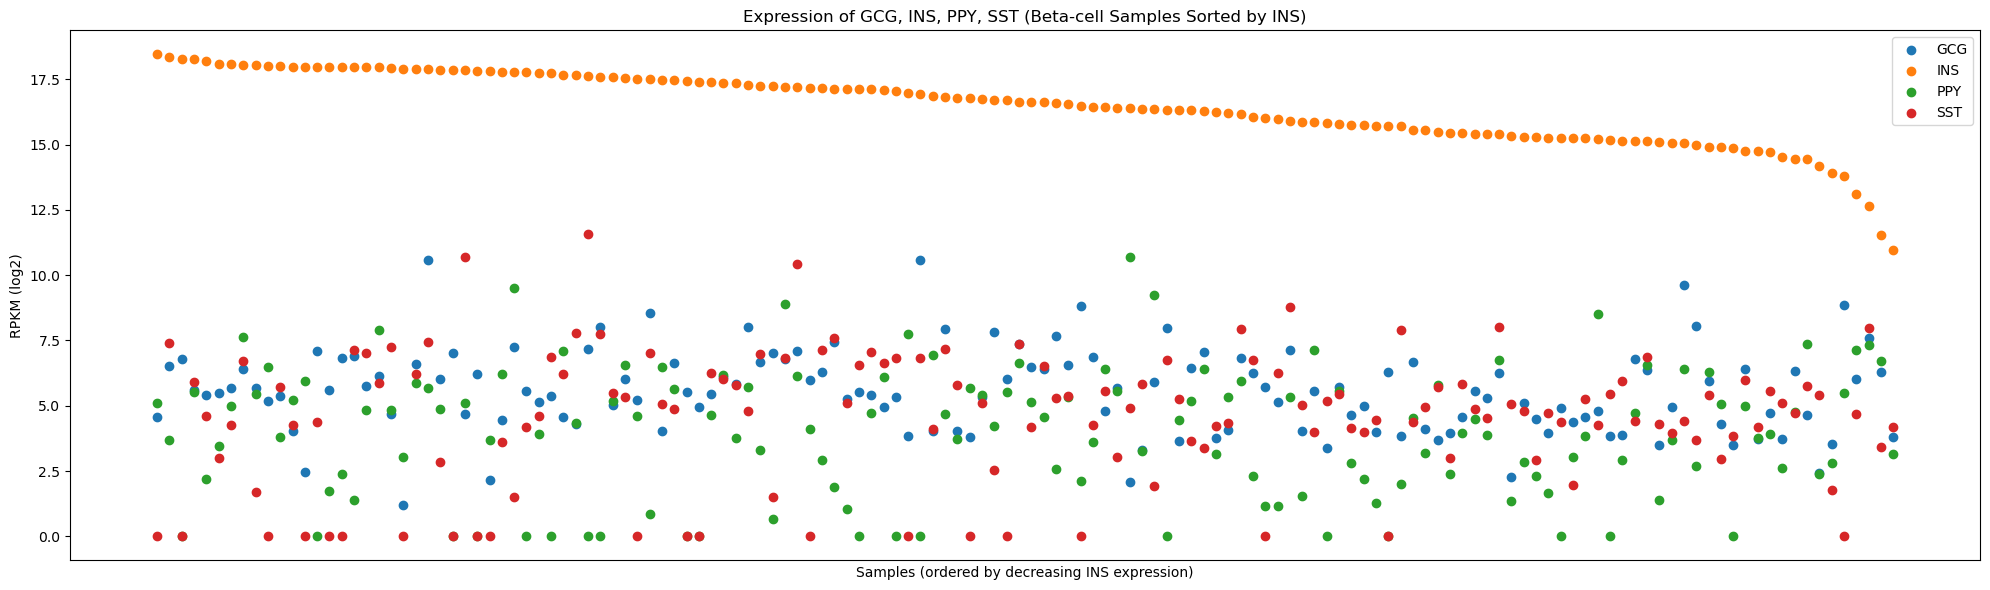

In [13]:
plt.figure(figsize=(20, 6))

for gene in ['GCG', 'INS', 'PPY', 'SST']:
    plt.scatter(log_subset_sorted.index, log_subset_sorted[gene], label=gene)

plt.xticks([], [])  # Hide sample names
plt.ylabel('RPKM (log2)')
plt.xlabel('Samples (ordered by decreasing INS expression)')
plt.title('Expression of GCG, INS, PPY, SST (Beta-cell Samples Sorted by INS)')
plt.legend()
plt.tight_layout()
plt.show()


## t-SNE (t-distributed Stochastic Neighbor Embedding)

### All 62710 Genes

In [14]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [73]:
# Drop the label column to get expression matrix
X = df_t.drop(columns=['condition', 'donor'])
X_log = np.log2(X + 1)

In [16]:
# PCA
X_pca = PCA(n_components=30).fit_transform(X_log)
# Run t-SNE
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_pca)

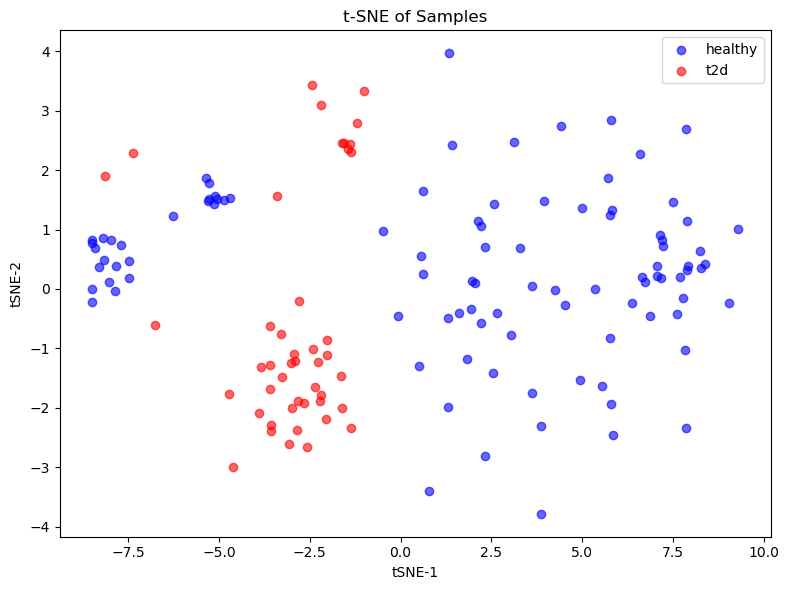

In [17]:
# Plot
plt.figure(figsize=(8, 6))
colors = {'healthy': 'blue', 't2d': 'red'}
for cond in df_t['condition'].unique():
    ix = df_t['condition'] == cond
    plt.scatter(X_tsne[ix, 0], X_tsne[ix, 1], label=cond, c=colors[cond], alpha=0.6)

plt.title('t-SNE of Samples')
plt.xlabel('tSNE-1')
plt.ylabel('tSNE-2')
plt.legend()
plt.tight_layout()
plt.show()

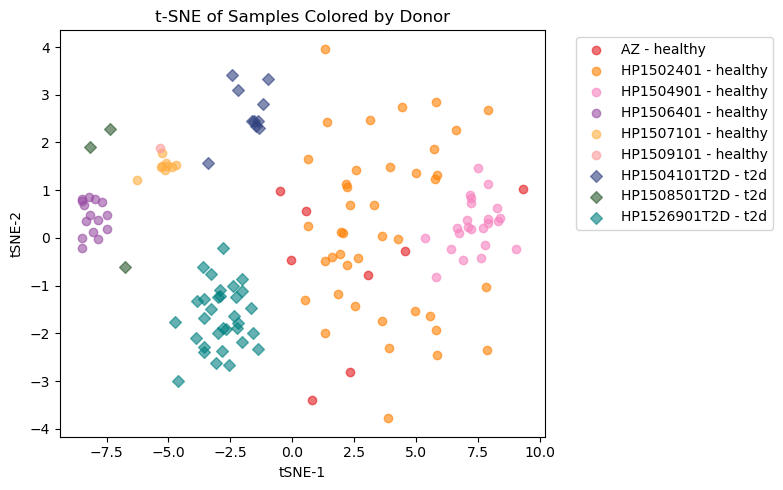

In [18]:
# Plot with donor-specific colors
plt.figure(figsize=(8, 5))
markers = {'healthy': 'o', 't2d': 'D'} 
colors = [
    "#e41a1c",  # warm - red
    "#ff7f00",  # warm - orange
    "#f781bf",  # warm - pink
    "#984ea3",  # warm - purple
    "#ffae42",  # warm - goldenrod
    "#fb9a99",  # warm - salmon

    "#30417f",  # cool - blue
    "#2b592e",  # cool - green
    "#008080"   # cool - teal
]
donors = df_t['donor'].unique()
donor_colors = dict(zip(donors, colors))

for donor in df_t['donor'].unique():
    ix = df_t['donor'].values == donor
    condition = df_t[df_t['donor'] == donor]['condition'].unique()[0]
    
    plt.scatter(
        X_tsne[ix, 0], 
        X_tsne[ix, 1], 
        label=f"{donor} - {condition}", 
        color=donor_colors[donor],
        marker=markers.get(condition, 'o'), 
        alpha=0.6
    )

plt.title('t-SNE of Samples Colored by Donor')
plt.xlabel('tSNE-1')
plt.ylabel('tSNE-2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Top 50 Most Variable Genes
Figure 4B-left

In [19]:
top_var_genes = X_log.var(axis=0).sort_values(ascending=False).head(50).index
X_top = X[top_var_genes]
X_top.shape

(142, 50)

In [20]:
X_pca = PCA(n_components=30).fit_transform(X_log)
tsne = TSNE(n_components=2, perplexity=30, random_state=23)
X_tsne = tsne.fit_transform(X_pca)

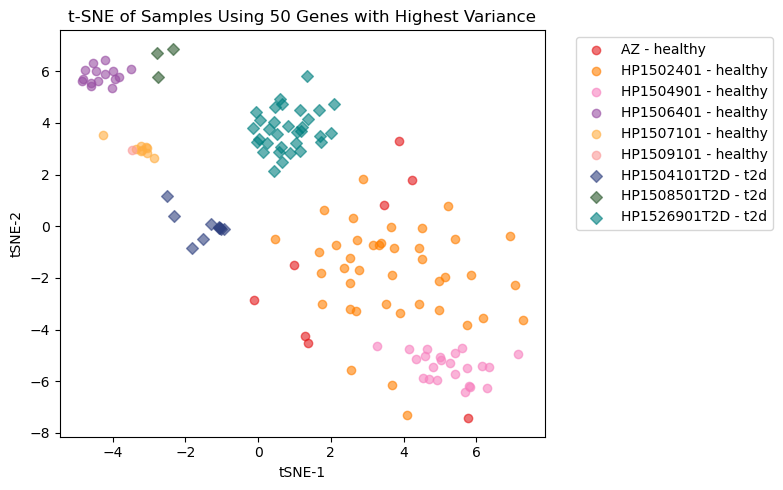

In [21]:
# Plot with donor-specific colors
plt.figure(figsize=(8, 5))
markers = {'healthy': 'o', 't2d': 'D'} 
colors = [
    "#e41a1c",  # warm - red
    "#ff7f00",  # warm - orange
    "#f781bf",  # warm - pink
    "#984ea3",  # warm - purple
    "#ffae42",  # warm - goldenrod
    "#fb9a99",  # warm - salmon

    "#30417f",  # cool - blue
    "#2b592e",  # cool - green
    "#008080"   # cool - teal
]
donors = df_t['donor'].unique()
donor_colors = dict(zip(donors, colors))

for donor in df_t['donor'].unique():
    ix = df_t['donor'].values == donor
    condition = df_t[df_t['donor'] == donor]['condition'].unique()[0]
    
    plt.scatter(
        X_tsne[ix, 0], 
        X_tsne[ix, 1], 
        label=f"{donor} - {condition}", 
        color=donor_colors[donor],
        marker=markers.get(condition, 'o'), 
        alpha=0.6
    )

plt.title('t-SNE of Samples Using 50 Genes with Highest Variance')
plt.xlabel('tSNE-1')
plt.ylabel('tSNE-2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Gene Expression Plots
DE genes (Figure 4B-right)

In [22]:
mg = mygene.MyGeneInfo()

# Query gene symbols
gene_symbols = ['INS', 'RBP4', 'FFAR4', 'ID1', 'ID2']
results = mg.querymany(gene_symbols, scopes='symbol', fields='ensembl.gene', species='human')

# Build dict symbol -> Ensembl ID
symbol_to_ensembl_DE = {r['query']: r['ensembl']['gene'] if isinstance(r['ensembl'], dict) else r['ensembl'][0]['gene']
                     for r in results if 'ensembl' in r}

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


gene ID3 (ENSG00000283060) is not present in the rpkm_combined.txt, so I omitted it.

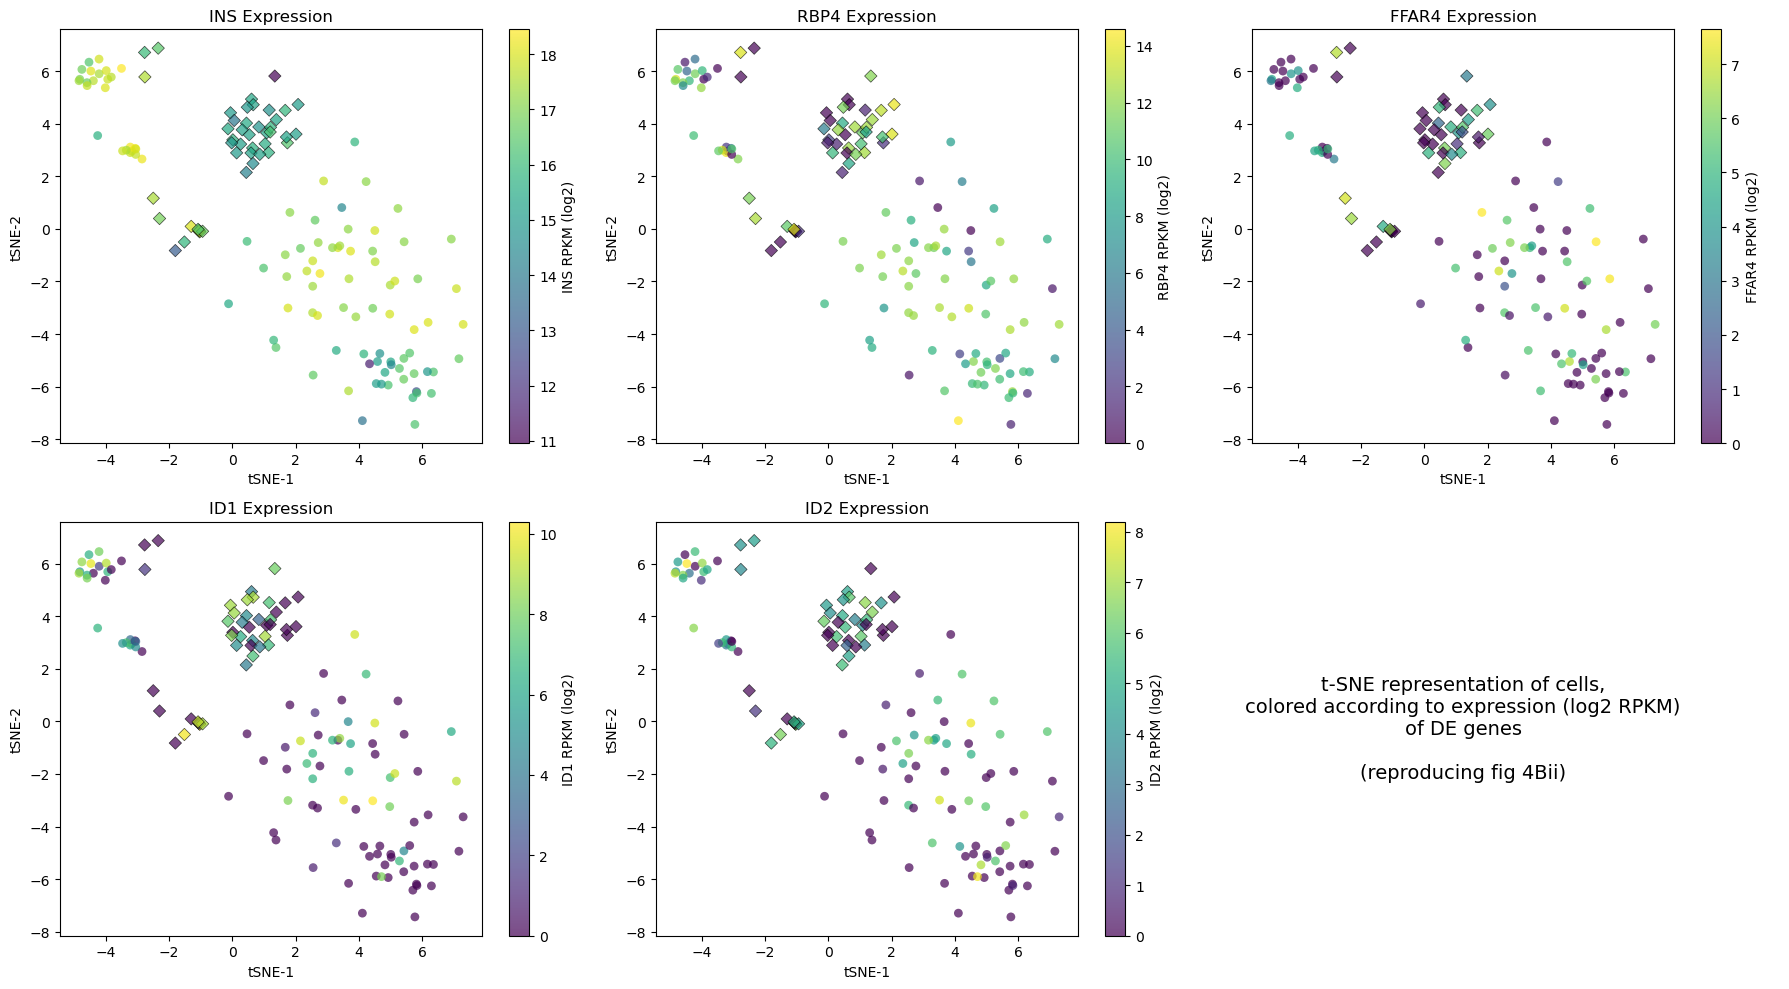

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Marker logic by condition
condition_markers = {'healthy': 'o', 't2d': 'D'}

for ax, gene_symbol in zip(axes, symbol_to_ensembl_DE.keys()):
    ensembl_id = symbol_to_ensembl_DE[gene_symbol]
    gene_expr = np.log2(df_t[ensembl_id] + 1)

    # Get min/max for color scale consistency
    vmin = gene_expr.min()
    vmax = gene_expr.max()

    for condition in ['healthy', 't2d']:
        ix = df_t['condition'] == condition
        marker = condition_markers[condition]
        
        sc = ax.scatter(
            X_tsne[ix.to_numpy(), 0],
            X_tsne[ix.to_numpy(), 1],
            c=gene_expr[ix],
            cmap='viridis',
            s=40,
            marker=marker,
            alpha=0.7,
            vmin=vmin,
            vmax=vmax,
            edgecolor='k' if marker == 'D' else 'none',
            linewidth=0.5
        )

    ax.set_title(f'{gene_symbol} Expression')
    ax.set_xlabel('tSNE-1')
    ax.set_ylabel('tSNE-2')

    # Add colorbar for each subplot
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(f'{gene_symbol} RPKM (log2)')

axes[-1].text(0.4, 0.5, 
              't-SNE representation of cells,\ncolored according to expression (log2 RPKM)\nof DE genes\n\n(reproducing fig 4Bii)', 
              ha='center', va='center', fontsize=14)
axes[-1].set_axis_off()

plt.tight_layout()
plt.show()


## Feature Selection

In [24]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Extract X (features) and y (labels)
X = df_t.drop(columns=['condition', 'donor'])
X_log = np.log2(X + 1)
y = df_t['condition']

# Encode 'healthy' = 0, 't2d' = 1
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [25]:
import json

query_cache_file = "query_result.json"

# Batch query: return gene symbol for each Ensembl ID (This will take 2 minutes)
if os.path.exists(query_cache_file):
    with open(query_cache_file, "r") as f:
        query_result = json.load(f)
    print(f"Loaded cached MyGene.info results from {query_cache_file}")
else:
    ensembl_ids = list(X.columns)
    mg = mygene.MyGeneInfo()
    query_result = mg.querymany(ensembl_ids, scopes='ensembl.gene', fields='symbol', species='human')

    # Save for future reuse
    with open(query_cache_file, "w") as f:
        json.dump(query_result, f)
    print(f"Fetched MyGene.info results and cached to {query_cache_file}")

# Build a mapping: ENSG ID → gene symbol
ensembl_to_symbol = {
    item['query']: item.get('symbol', item['query'])  # fallback to ENSG ID if no symbol found
    for item in query_result
}

no_hit_count = sum(1 for item in query_result if item.get('notfound', False))
print(f"{len(ensembl_to_symbol) - no_hit_count} of {len(X.columns)} ensembl to symbol mapped")

Loaded cached MyGene.info results from query_result.json
61474 of 62710 ensembl to symbol mapped


In [82]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, stratify=y_encoded, test_size=0.3, random_state=23)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
#clf = LogisticRegression(penalty='l2', solver='saga', max_iter=1000, random_state=23)
clf = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=23) # l1 or l2 penalty
#clf = LogisticRegression(penalty=None, max_iter=1000, random_state=23)

clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000, penalty='l1', random_state=23,
                   solver='liblinear')

In [83]:
feature_importance = pd.Series(clf.coef_[0], index=X_train.columns)
top_genes = feature_importance.abs().sort_values(ascending=False).head(15)
top_genes_named = top_genes.rename(index=lambda ensg: ensembl_to_symbol.get(ensg, ensg))
top_genes_named


TRNM               0.006479
RN7SL1             0.006218
SST                0.005725
EIF4EBP1           0.003685
GDF15              0.002819
NPTX2              0.002754
CPE                0.002678
JUNB               0.001988
ENSG00000256148    0.001932
HLA-E              0.001811
SCG2               0.001711
SHISAL2B           0.001105
PCSK1N             0.001099
GPX3               0.000949
H4C3               0.000843
dtype: float64

In [84]:
t2d_linked_genes = ['PHF2', 'GCK', 'SLC30A8', 'IRS1', 'SREBF1', 
                    'KCNJ11', 'CDKAL1', 'AZF1', 'GLIS3', 'ZNRF3']

t2d_linked_ensembl = []
for ensembl, symbol in ensembl_to_symbol.items():
    if symbol in t2d_linked_genes:
        t2d_linked_ensembl.append(ensembl)

for ensembl in t2d_linked_ensembl:
    print(feature_importance[ensembl])

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [87]:
# These are genes commonly-linked to T2D
t2d_genes = [
    "TCF7L2", "CDKAL1", "KCNJ11", "PPARG", "HHEX", "SLC30A8", "IGF2BP2", "CDKN2A", "CDKN2B",
    "FTO", "MC4R", "CDC123", "PHF2", "SLC16A11", "ANK1", "NOTCH2", "JAZF1", "WFS1", "GLIS3",
    "GCK", "GCKR", "HNF1A", "HNF4A", "PAX5", "TET1", "CHL1", "GLRA1", "IAPP", "CAPN10", "ABCC8",
    "GCGR", "ADAMTS9", "ADIPOQ", "IRS1", "SREBF1", "EXT2", "MEF2C", "TMEM161B", "CEP120", 
    "PRDM6", "STEAP1", "ZNF804B", "ZNRF3", "PRIM1", "IRF2BPL", "LRRC74A"
]

set(top_genes_named.index) & set(t2d_genes)

{'CDKAL1',
 'GCK',
 'GLIS3',
 'IRS1',
 'KCNJ11',
 'PHF2',
 'SLC30A8',
 'SREBF1',
 'ZNRF3'}

In [ ]:
plt.figure(figsize=(10, 4))
colors = ['red' if gene in t2d_linked_genes else 'blue' for gene in top_genes_named.index]
top_genes_named.plot(kind='barh', color=colors)
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.ylabel('Gene Symbol\n(red genes linked to T2D)')
plt.title('Top 15 Predictive Genes (Healthy vs T2D)')
plt.text(0.98, 0.05, "Logistical Regression Model\nL2 Regularization",
         ha='right', va='bottom',
         transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


The following genes have been linked to T2D:

['PHF2', 'GCK', 'SLC30A8', 'IRS1', 'SREBF1', 'KCNJ11', 'CDKAL1', 'AZF1', 'GLIS3', 'ZNRF3']

The most predictive gene is IRF2BPL. This gene encodes a transcription factor that may play a role in regulating female reproductive function. [provided by RefSeq, Jun 2012].  It is quite predictive likely because a sex imbalance between health and T2D donors.

M:F donors

5:1 healthy

2:2 T2D

### Retrieve Function and Ontology of top predictor genes.

In [ ]:
gene_names = [gene for gene in top_genes_named.keys()]

mg = mygene.MyGeneInfo()
fields = 'name,symbol,summary,go'

# Query MyGene.info
results = mg.querymany(gene_names, scopes='symbol', fields=fields, species='human')
len(results)


In [ ]:
def extract_terms(val):
    if isinstance(val, list):
        return '; '.join([v.get('term', '') for v in val])
    elif isinstance(val, dict):
        return val.get('term', '')
    return ''

# Parse results
data = []
for entry in results:
    if 'notfound' in entry and entry['notfound']:
        data.append({'symbol': entry['query'], 'summary': 'Not found', 'GO_BP': '', 'GO_MF': '', 'GO_CC': ''})
        continue

    go = entry.get('go', {})
    bp = extract_terms(go.get('BP'))
    mf = extract_terms(go.get('MF'))
    cc = extract_terms(go.get('CC'))

    data.append({
        'symbol': entry.get('symbol', ''),
        'name': entry.get('name', ''),
        'summary': entry.get('summary', ''),
        'GO_BP': bp,
        'GO_MF': mf,
        'GO_CC': cc
    })

# Save and print
df = pd.DataFrame(data)
print(df.to_string(index=False))
# df.to_csv('gene_function_ontology.csv', index=False)
# df.to_csv('gene_function_ontology.csv', mode="a", header=False, index=False)

### Run model with only T2D-linked genes

In [ ]:
mg = mygene.MyGeneInfo()
results = mg.querymany(t2d_genes, scopes='symbol', fields='ensembl.gene,symbol', species='human')

In [ ]:
# Step 2: Extract valid Ensembl gene IDs
ensembl_ids = []
for r in results:
    if 'ensembl' in r:
        if isinstance(r['ensembl'], list):
            ensembl_ids.extend([e['gene'] for e in r['ensembl']])
        else:
            ensembl_ids.append(r['ensembl']['gene'])

ensembl_ids

In [109]:
columns_to_keep = [col for col in ensembl_ids if col in df_t.columns]
t2d_df = df_t[columns_to_keep + ['condition', 'donor']].copy()

In [96]:
from sklearn.ensemble import RandomForestClassifier

# Split data (optional but good practice)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, stratify=y, test_size=0.2, random_state=23)

# Train model
clf = RandomForestClassifier(n_estimators=100, random_state=23)
clf.fit(X_train, y_train)


RandomForestClassifier(random_state=23)

In [98]:
# Extract feature importance
feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
top_genes = feature_importances.sort_values(ascending=False).head(20)

# Map feature names to symbols where possible
top_genes_named = top_genes.rename(index=lambda ensg: ensembl_to_symbol.get(ensg, ensg))


In [ ]:
plt.figure(figsize=(8, 6))
top_genes_named.plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.title('Top 20 Predictive Genes (Healthy vs T2D)')
plt.tight_layout()
plt.show()
